In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib 
import numpy as np
import os 
from sqlalchemy import create_engine
from urllib.parse import quote_plus 

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

%matplotlib inline

In [2]:
DB_USER = "myvolt_admin" 
DB_PASS = "M%R^N!J%IDKS$8@zya4v"
DB_HOST = "myvolt-db.postgres.database.azure.com"
DB_PORT = "5432"
DB_NAME = "postgres" 

DB_PASS_ENCODED = quote_plus(DB_PASS)

try:
    connection_string = f"postgresql+psycopg2://{DB_USER}:{DB_PASS_ENCODED}@{DB_HOST}:{DB_PORT}/{DB_NAME}?sslmode=require"
    engine = create_engine(connection_string)
    with engine.connect() as conn:
        print("¡Conexión a Azure PostgreSQL exitosa!")
except Exception as e:
    print(f"Error al conectar a Azure: {e}")

¡Conexión a Azure PostgreSQL exitosa!


In [3]:
query = """
SELECT time, power_w
FROM consumption_data
WHERE id_device = (
    SELECT id_device 
    FROM devices 
    WHERE mac_address = '14:2B:2F:C2:09:08' -- ¡Verifica que sea tu MAC real!
)
ORDER BY time DESC
LIMIT 15000; 
"""

df = pd.read_sql_query(query, con=engine)

print(f"¡Éxito! Se cargaron {len(df)} registros REALES desde la base de datos.")
# Muestra los primeros 5 y una descripción estadística para ver los rangos reales
display(df.head())
display(df.describe())

¡Éxito! Se cargaron 12539 registros REALES desde la base de datos.


,time,power_w
0,2025-11-13 05:11:10.535920+00:00,34.01
1,2025-11-13 05:11:09.930659+00:00,27.21
2,2025-11-13 05:11:08.748569+00:00,34.01
3,2025-11-13 05:11:07.783256+00:00,27.21
4,2025-11-13 05:11:06.703376+00:00,34.01


,power_w
count,12539.000000
mean,18.815046
std,15.538429
min,0.000000
25%,0.000000
50%,27.210000
75%,34.010000
max,319.730000


In [4]:
# 1. Seleccionamos solo la columna de potencia
datos_para_modelo = df[['power_w']]

# 2. Creamos y entrenamos el escalador
scaler = MinMaxScaler()
datos_escalados = scaler.fit_transform(datos_para_modelo)

print("Datos reales escalados (0 a 1):")
print(datos_escalados[:5])

Datos reales escalados (0 a 1):
[[0.106371  ]
 [0.08510306]
 [0.106371  ]
 [0.08510306]
 [0.106371  ]]


In [5]:
# Arquitectura del Autoencoder
input_layer = Input(shape=(1,))
encoder = Dense(8, activation='relu')(input_layer)
encoder = Dense(4, activation='relu')(encoder) # Cuello de botella
decoder = Dense(8, activation='relu')(encoder)
decoder = Dense(1, activation='sigmoid')(decoder) 

autoencoder = Model(inputs=input_layer, outputs=decoder)
autoencoder.compile(optimizer='adam', loss='mae', metrics=['mae'])
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101 (404.00 B)

 Trainable params: 101 (404.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
historial = autoencoder.fit(
    datos_escalados, 
    datos_escalados, 
    epochs=50, 
    batch_size=32,
    shuffle=True,
    validation_split=0.1 
)
print("Modelo entrenado con datos reales")

Epoch 1/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1702 - mae: 0.1702 - val_loss: 0.0213 - val_mae: 0.0213
Epoch 2/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0473 - mae: 0.0473 - val_loss: 0.0184 - val_mae: 0.0184
Epoch 3/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0421 - mae: 0.0421 - val_loss: 0.0162 - val_mae: 0.0162
Epoch 4/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0345 - mae: 0.0345 - val_loss: 0.0111 - val_mae: 0.0111
Epoch 5/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0198 - mae: 0.0198 - val_loss: 0.0044 - val_mae: 0.0044
Epoch 6/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0115 - mae: 0.0115 - val_loss: 0.0056 - val_mae: 0.0056
Epoch 7/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0098 - mae: 0.0098 - val_loss: 0.0071 - val_mae: 0.0071
Epoch 8/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0092 - mae: 0.0092 - val_loss: 0.0081 - val_mae: 0.0081
Epoch 9/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - lo

In [8]:
# 1. Reconstruir los datos
datos_reconstruidos = autoencoder.predict(datos_escalados)
errores = mean_absolute_error(datos_escalados.T, datos_reconstruidos.T, multioutput='raw_values')
df['error_nn'] = errores

# 2. Definir umbral (98% de confianza)
umbral = np.percentile(df['error_nn'], 98)

# 3. Calcular "precisión"
final_error = historial.history['val_loss'][-1]
print(f"Error Final: {final_error:.6f}")
print(f"Precisión de Reconstrucción: {(1 - final_error) * 100:.2f}%")
print(f"Umbral de Anomalía Real: {umbral}")

392/392 ━━━━━━━━━━━━━━━━━━━━ 0s 715us/step
Error Final: 0.010163
Precisión de Reconstrucción: 98.98%
Umbral de Anomalía Real: 0.01921900199612682


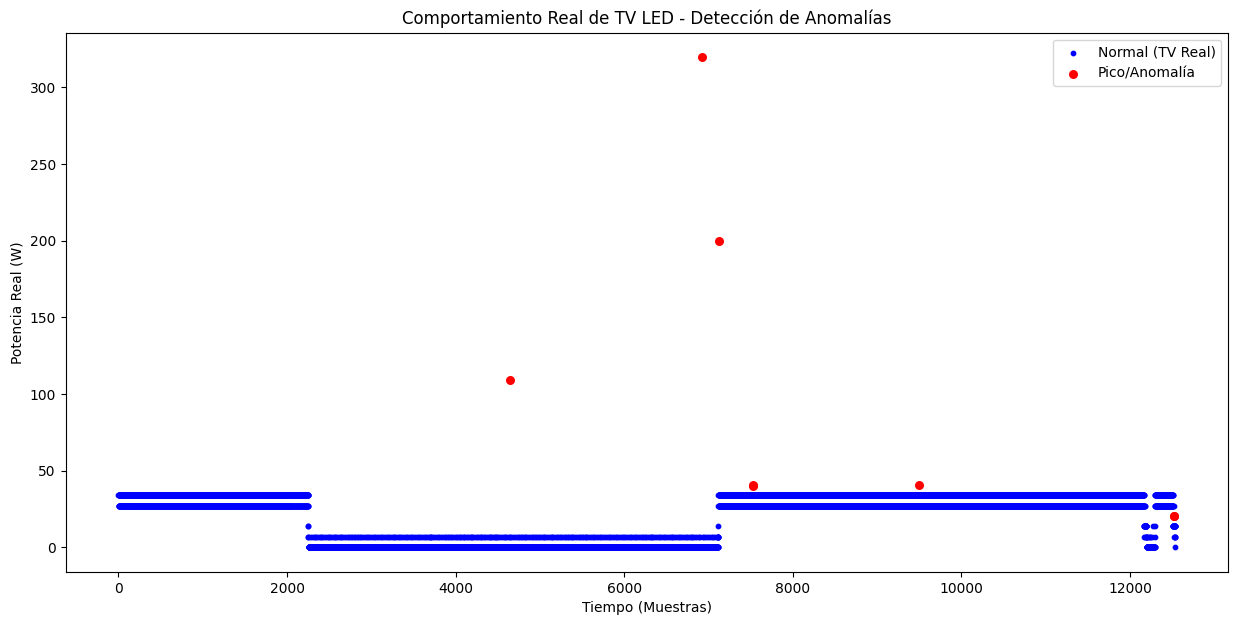

In [9]:
df['anomalia_nn'] = df['error_nn'] > umbral
df_normal = df[df['anomalia_nn'] == False]
df_anomalo = df[df['anomalia_nn'] == True]

plt.figure(figsize=(15, 7))
plt.scatter(df_normal.index, df_normal['power_w'], c='blue', label='Normal (TV Real)', s=10)
plt.scatter(df_anomalo.index, df_anomalo['power_w'], c='red', label='Pico/Anomalía', s=30)

plt.title('Comportamiento Real de TV LED - Detección de Anomalías')
plt.xlabel('Tiempo (Muestras)')
plt.ylabel('Potencia Real (W)')
plt.legend()
plt.show()

In [10]:
# Rutas
ruta_modelo_nn = '../neural_network/RN_DT_tv_led_real_autoencoder_v1.h5'
ruta_scaler_nn = '../scaler/DT_tv_led_real_scaler_v1.pkl'

# Crear carpetas si no existen
os.makedirs(os.path.dirname(ruta_modelo_nn), exist_ok=True)
os.makedirs(os.path.dirname(ruta_scaler_nn), exist_ok=True)

# Guardar
autoencoder.save(ruta_modelo_nn)
joblib.dump(scaler, ruta_scaler_nn)

print(f"¡Modelo REAL guardado en: {ruta_modelo_nn}!")

¡Modelo REAL guardado en: ../neural_network/RN_DT_tv_led_real_autoencoder_v1.h5!
